## Desafio Aprendizado de Máquina - Módulo 4

### Import das bibliotecas

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Criação dos dados fornecidos

In [2]:
dados_vendas = {
    'mes': [
      'Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',  'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'
    ],
    'vendas': [
       2000, 2200, 2300, 2500, 2600, 2700,
       2800, 2900, 3000, 3100, 3200, 3300
    ]
}

### Tratamento e Formatação dos Dados

In [3]:
# Criação do DataFrame
df_vendas = pd.DataFrame.from_dict(dados_vendas)

In [4]:
# Teste
df_vendas

,mes,vendas
0,Janeiro,2000
1,Fevereiro,2200
2,Março,2300
3,Abril,2500
4,Maio,2600
5,Junho,2700
6,Julho,2800
7,Agosto,2900
8,Setembro,3000
9,Outubro,3100


In [5]:
# Verificar estrutura / schema
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   mes     12 non-null     str  
 1   vendas  12 non-null     int64
dtypes: int64(1), str(1)
memory usage: 324.0 bytes


In [6]:
# Converter mês em número
df_vendas['mes_num'] = range(1, len(df_vendas)+1)

In [7]:
# Remover coluna mes (string)
df_vendas.drop(columns='mes', inplace=True)

In [8]:
# Teste
df_vendas

,vendas,mes_num
0,2000,1
1,2200,2
2,2300,3
3,2500,4
4,2600,5
5,2700,6
6,2800,7
7,2900,8
8,3000,9
9,3100,10


<Axes: xlabel='mes_num', ylabel='vendas'>

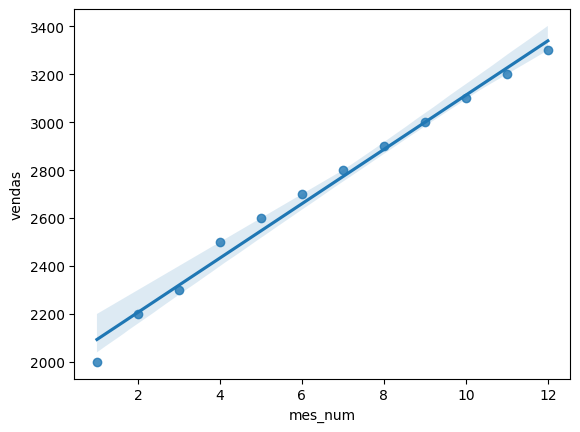

In [22]:
# Visualizar regressão linear simples
sns.regplot(data=df_vendas, x="mes_num", y="vendas")

### Treinar o modelo

In [9]:
# Importar bibliotecas do sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
# Modelo 
X = df_vendas.drop(columns=['vendas'])
y = df_vendas['vendas']

In [11]:
# Dividir conjunto entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [12]:
# Treinar o algoritmo de Regressão Linear
model = LinearRegression().fit(X_train, y_train)

In [13]:
# Gerar predições do conjunto de testes
y_pred = model.predict(X_test)

In [14]:
# Verificar predição
y_pred

array([2420.        , 2876.66666667, 2305.83333333, 2762.5       ])

In [15]:
# Coeficiente angular
model.coef_

array([114.16666667])

In [16]:
# Coeficiente linear
model.intercept_

np.float64(1963.3333333333333)

In [17]:
# R2 Score - Conjunto de Treinamento
model.score(X_train, y_train)

0.990709949854843

In [18]:
# R2 Score - Conjunto de Testes
model.score(X_test, y_test)

0.9631440781440782

In [29]:
# R2 Score - Conjunto de Testes (v2)
r2_score(y_test, y_pred)

0.9631440781440782

In [19]:
# MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

36.66666666666663

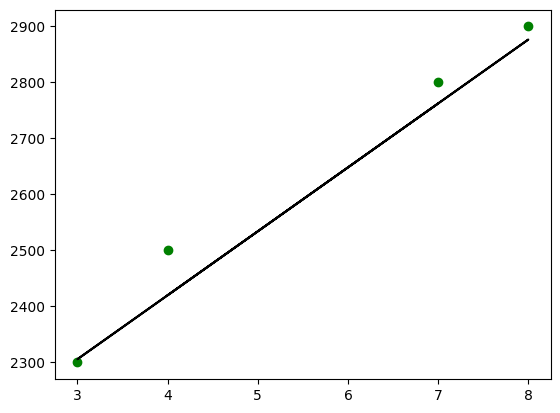

In [34]:
# Mostrar como a reta foi calculada
# (apenas pontos de treino)
plt.scatter(X_test,y_test, color='g')
plt.plot(X_test, y_pred, color='k')

### Prever a venda de dezembro

In [42]:
# Prevê e mostra a venda de dezembro 
# Para comparação, dado real vendas[dez] = 3300
prev_dez = model.predict([[12]])
prev_dez

c:\Users\anitaa\.virtualenvs\scikit_learn_first_model-wTYh6TSR\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3333.33333333])

### Montar um histograma dos dados

array([[<Axes: title={'center': 'vendas'}>,
        <Axes: title={'center': 'mes_num'}>]], dtype=object)

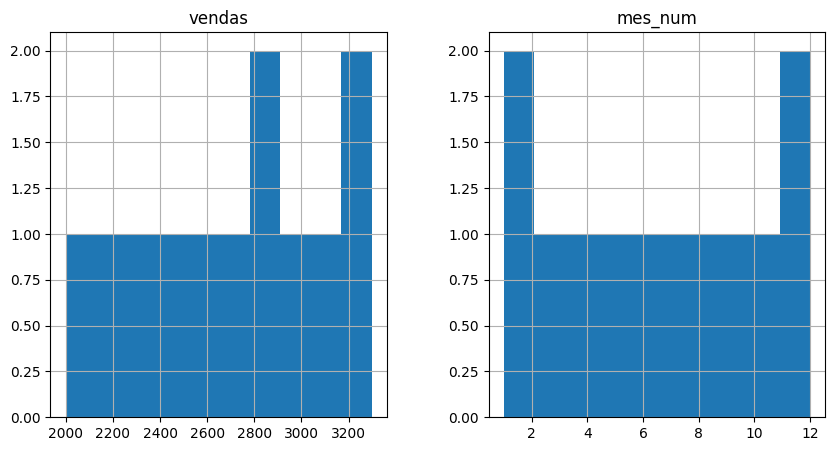

In [27]:
df_vendas.hist(bins=10, figsize=(10,5))

### Montar um plot de scatter

array([[<Axes: xlabel='vendas', ylabel='vendas'>,
        <Axes: xlabel='mes_num', ylabel='vendas'>],
       [<Axes: xlabel='vendas', ylabel='mes_num'>,
        <Axes: xlabel='mes_num', ylabel='mes_num'>]], dtype=object)

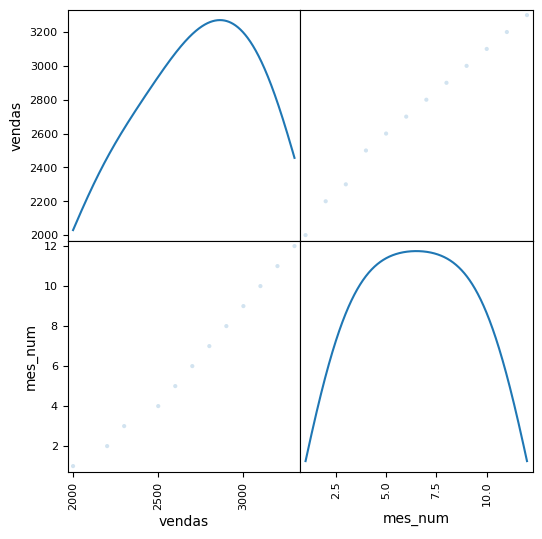

In [32]:
# Mostrar como a reta foi calculada
pd.plotting.scatter_matrix(df_vendas, alpha=0.2, figsize=(6,6), diagonal='kde')